Using device: cpu
Random seed set to: 1234
Using 256 fixed source sensors for branch input.
Epoch     1 | Loss: 1.952e+01 (PDE: 1.952e+01, BC(mon.): 0.000e+00, lr=1.0e-03)
Epoch   200 | Loss: 9.284e-01 (PDE: 9.284e-01, BC(mon.): 0.000e+00, lr=1.0e-03)
Epoch   400 | Loss: 3.272e-01 (PDE: 3.272e-01, BC(mon.): 0.000e+00, lr=1.0e-03)
Epoch   600 | Loss: 1.761e-01 (PDE: 1.761e-01, BC(mon.): 0.000e+00, lr=1.0e-03)
Epoch   800 | Loss: 1.795e-01 (PDE: 1.795e-01, BC(mon.): 0.000e+00, lr=1.0e-03)
Epoch  1000 | Loss: 1.038e-01 (PDE: 1.038e-01, BC(mon.): 0.000e+00, lr=1.0e-03)
Epoch  1200 | Loss: 6.242e-02 (PDE: 6.242e-02, BC(mon.): 0.000e+00, lr=1.0e-03)
Epoch  1400 | Loss: 4.902e-02 (PDE: 4.902e-02, BC(mon.): 0.000e+00, lr=1.0e-03)
Epoch  1600 | Loss: 2.429e+00 (PDE: 2.429e+00, BC(mon.): 0.000e+00, lr=5.0e-04)
Epoch  1800 | Loss: 6.907e-01 (PDE: 6.907e-01, BC(mon.): 0.000e+00, lr=5.0e-04)
Epoch  2000 | Loss: 4.031e-01 (PDE: 4.031e-01, BC(mon.): 0.000e+00, lr=5.0e-04)
Epoch  2200 | Loss: 1.034e+0

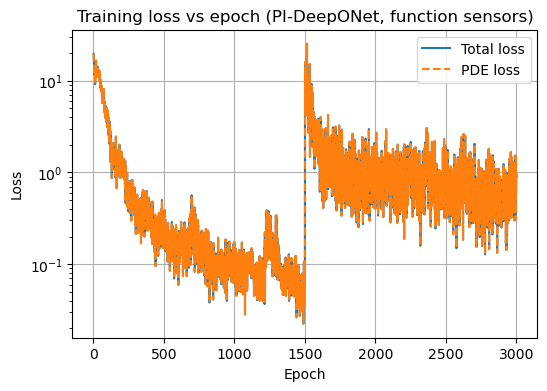

/tmp/ipykernel_12670/4236004867.py:387: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.xlabel("Epoch"); plt.ylabel("BC loss"); plt.yscale("log")


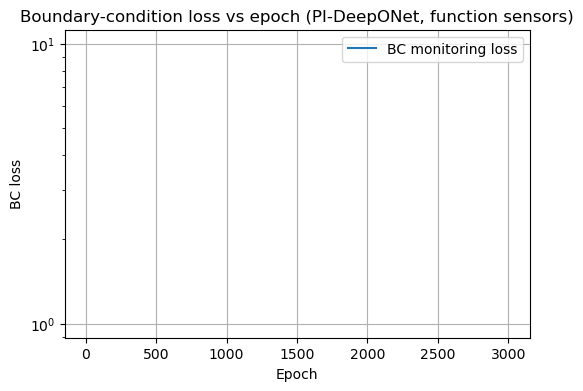

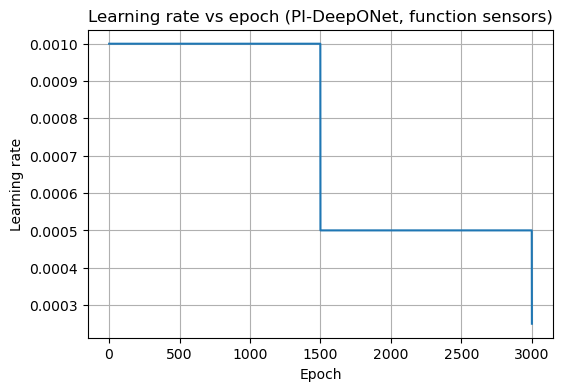

/tmp/ipykernel_12670/4236004867.py:570: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))


Loaded model from: pideeponet_poisson_function_sensor_model.pt

=== Test case 1/4: center_in_range ===
  (x0, y0, nu) = (0.500, 0.500, 0.070)
  Relative L2 error = 2.946e-02
  Saved per-case arrays to: outputs_pideeponet/pideeponet_case_00_center_in_range.npz

=== Test case 2/4: off_center_in_range ===
  (x0, y0, nu) = (0.450, 0.550, 0.090)
  Relative L2 error = 1.345e-02
  Saved per-case arrays to: outputs_pideeponet/pideeponet_case_01_off_center_in_range.npz

=== Test case 3/4: shifted_out_of_range ===
  (x0, y0, nu) = (0.300, 0.300, 0.060)
  Relative L2 error = 4.129e-01
  Saved per-case arrays to: outputs_pideeponet/pideeponet_case_02_shifted_out_of_range.npz

=== Test case 4/4: narrow_out_of_range ===
  (x0, y0, nu) = (0.500, 0.500, 0.030)
  Relative L2 error = 1.543e-01
  Saved per-case arrays to: outputs_pideeponet/pideeponet_case_03_narrow_out_of_range.npz

Saved solution comparison figure to: figures/pideeponet_poisson_function_sensor_results.png


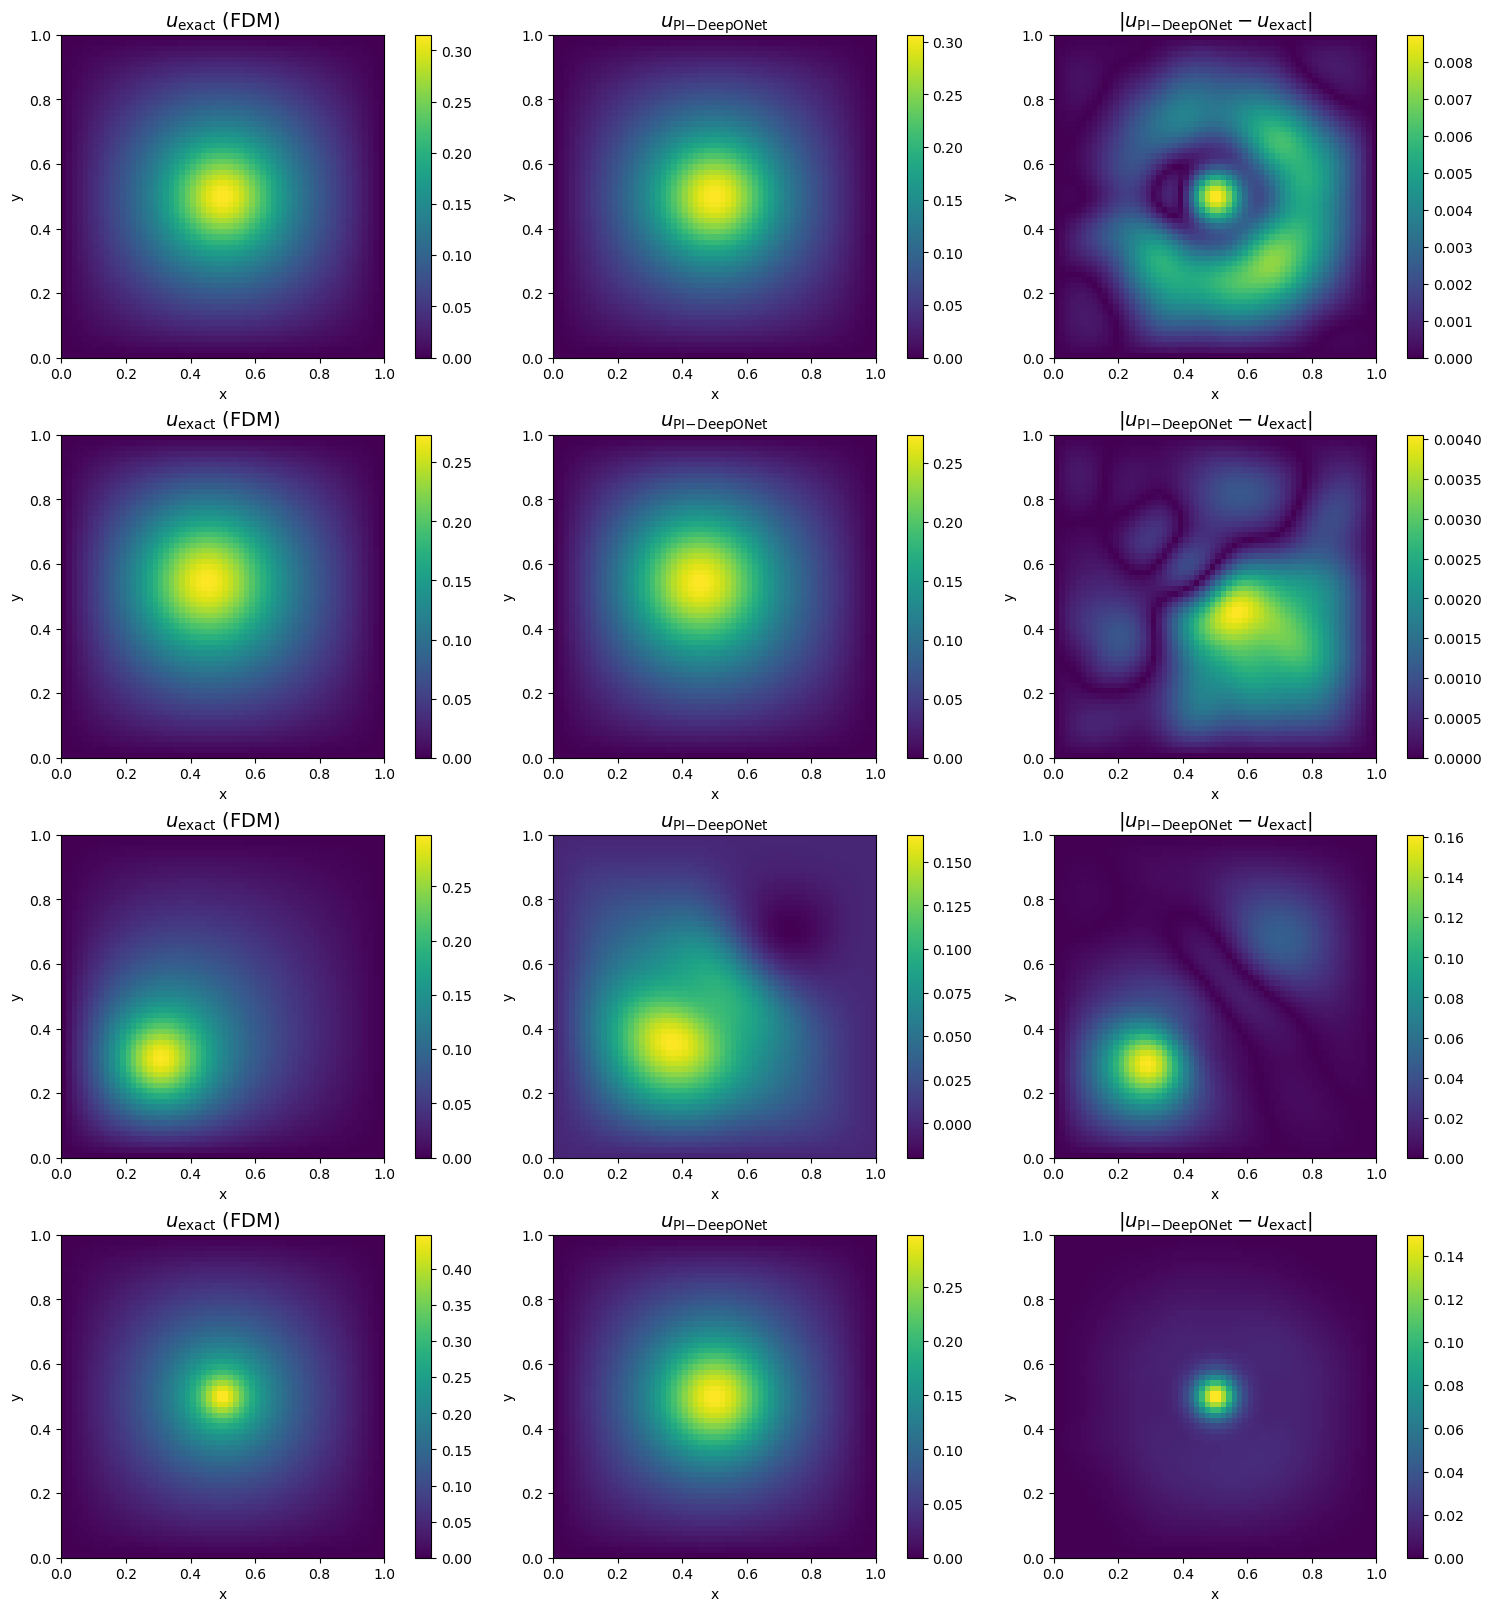


[Saved standardized bundle] outputs_pideeponet/pideeponet_bundle.npz
Bundle contains: x, y, params, case_names, u_exact, u_pred, abs_error (+ optional extras)

Summary of relative L2 errors:
  center_in_range          : 2.946e-02
  off_center_in_range      : 1.345e-02
  shifted_out_of_range     : 4.129e-01
  narrow_out_of_range      : 1.543e-01

Done.
Current directory: /home/vikas/Desktop/TWO_SHOTS/Vs_Neural_Operators/Poisson
Files: ['Poisson_03_PIDeepONet.ipynb', 'PLOTTING_CODE.ipynb', 'Poisson_02_HyperPINN.ipynb', 'Poisson_01_KAPI.ipynb', '.ipynb_checkpoints', 'figures', 'pideeponet_poisson_function_sensor_model.pt', 'outputs_pideeponet']


In [1]:
"""
PI-DeepONet (function-sensor version) for 2D Poisson with Gaussian source on [0,1]^2:
    -Δu = f(x,y; x0, y0, nu),   u = 0 on boundary.

Updated for structural consistency with the advection PI-DeepONet:
  - branch input = sampled source function values at fixed sensor points
  - trunk input  = query coordinates (x,y)
  - hard Dirichlet BC enforced via x(1-x)y(1-y)
  - standardized export preserved:
      x, y, params, case_names, u_exact, u_pred, abs_error
"""

import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

# ============================================================
# Device + reproducibility
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

DATA_DIR = "outputs_pideeponet"
os.makedirs(DATA_DIR, exist_ok=True)

MODEL_PATH = "pideeponet_poisson_function_sensor_model.pt"

SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print("Random seed set to:", SEED)

# ============================================================
# Problem definition
# ============================================================
def gaussian_source(x, y, x0, y0, nu):
    r2 = (x - x0) ** 2 + (y - y0) ** 2
    return (1.0 / (2.0 * torch.pi * nu**2)) * torch.exp(-r2 / (2.0 * nu**2))

x0_min, x0_max = 0.4, 0.6
y0_min, y0_max = 0.4, 0.6
nu_min, nu_max = 0.05, 0.1

def sample_pde_param(nu_min_curr=None, nu_max_curr=None):
    if nu_min_curr is None:
        nu_min_curr = nu_min
    if nu_max_curr is None:
        nu_max_curr = nu_max

    x0 = x0_min + (x0_max - x0_min) * torch.rand(1, device=device)
    y0 = y0_min + (y0_max - y0_min) * torch.rand(1, device=device)

    u = torch.rand(1, device=device)
    nu_min_t = torch.tensor(nu_min_curr, device=device)
    nu_max_t = torch.tensor(nu_max_curr, device=device)
    nu = 10.0 ** (
        torch.log10(nu_min_t)
        + (torch.log10(nu_max_t) - torch.log10(nu_min_t)) * u
    )

    p = torch.stack([x0, y0, nu], dim=-1)
    return p


def sample_collocation_points_p_dependent(
    N_int, N_bc, p, alpha=None, sigma_factor=3.0, device=device
):
    x0, y0, nu = p[0]

    if alpha is None:
        alpha = 0.9 if nu.item() < 0.06 else 0.7

    N_loc = int(alpha * N_int)
    N_uni = N_int - N_loc

    if N_loc > 0:
        loc_x = x0 + sigma_factor * nu * torch.randn(N_loc, 1, device=device)
        loc_y = y0 + sigma_factor * nu * torch.randn(N_loc, 1, device=device)
        loc_x = loc_x.clamp(0.0, 1.0)
        loc_y = loc_y.clamp(0.0, 1.0)
        xy_loc = torch.cat([loc_x, loc_y], dim=1)
    else:
        xy_loc = torch.empty(0, 2, device=device)

    if N_uni > 0:
        uni_x = torch.rand(N_uni, 1, device=device)
        uni_y = torch.rand(N_uni, 1, device=device)
        xy_uni = torch.cat([uni_x, uni_y], dim=1)
    else:
        xy_uni = torch.empty(0, 2, device=device)

    xy_int = torch.cat([xy_loc, xy_uni], dim=0)

    if N_bc > 0:
        N_side = N_bc // 4
        t = torch.rand(N_side, 1, device=device)

        xb = torch.cat(
            [
                torch.zeros(N_side, 1, device=device),
                torch.ones(N_side, 1, device=device),
                t,
                t,
            ],
            dim=0,
        )
        yb = torch.cat(
            [
                t,
                t,
                torch.zeros(N_side, 1, device=device),
                torch.ones(N_side, 1, device=device),
            ],
            dim=0,
        )
        xy_bc = torch.cat([xb, yb], dim=1)
    else:
        xy_bc = torch.empty(0, 2, device=device)

    return xy_int, xy_bc


# ============================================================
# FDM "exact" solver
# ============================================================
def poisson_exact_fdm(N=60, x0=0.5, y0=0.5, nu=0.05):
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    dx = x[1] - x[0]
    X, Y = np.meshgrid(x, y, indexing="ij")

    r2 = (X - x0) ** 2 + (Y - y0) ** 2
    f = (1.0 / (2.0 * np.pi * nu**2)) * np.exp(-r2 / (2.0 * nu**2))

    Nint = N - 2
    f_inner = f[1:-1, 1:-1].reshape(-1)

    e = np.ones(Nint)
    D2 = (np.diag(-2 * e) + np.diag(e[:-1], 1) + np.diag(e[:-1], -1)) / dx**2
    I = np.eye(Nint)

    L = np.kron(I, D2) + np.kron(D2, I)
    rhs = -f_inner

    u_inner = np.linalg.solve(L, rhs)
    u = np.zeros((N, N))
    u[1:-1, 1:-1] = u_inner.reshape(Nint, Nint)
    return x, y, u


# ============================================================
# Test cases
# ============================================================
test_cases = [
    ("center_in_range",      0.50, 0.50, 0.07),
    ("off_center_in_range",  0.45, 0.55, 0.09),
    ("shifted_out_of_range", 0.30, 0.30, 0.06),
    ("narrow_out_of_range",  0.50, 0.50, 0.03),
]

# ============================================================
# Fixed function sensors for branch input
# ============================================================
SENSOR_NX = 16
SENSOR_NY = 16

sensor_x = np.linspace(0.0, 1.0, SENSOR_NX, dtype=np.float32)
sensor_y = np.linspace(0.0, 1.0, SENSOR_NY, dtype=np.float32)
SX, SY = np.meshgrid(sensor_x, sensor_y, indexing="ij")
SENSOR_XY = np.stack([SX.reshape(-1), SY.reshape(-1)], axis=1).astype(np.float32)
N_SENSORS = SENSOR_XY.shape[0]

print(f"Using {N_SENSORS} fixed source sensors for branch input.")

def build_branch_input_from_p(p, device=device):
    sensor_xy_t = torch.tensor(SENSOR_XY, dtype=torch.float32, device=device)
    xs = sensor_xy_t[:, 0]
    ys = sensor_xy_t[:, 1]
    x0, y0, nu = p[0, 0], p[0, 1], p[0, 2]
    v = gaussian_source(xs, ys, x0, y0, nu).view(1, -1)
    return v

# ============================================================
# DeepONet model definition (function-sensor version)
# ============================================================
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, depth=3, act=nn.Tanh):
        super().__init__()
        layers = []
        d = in_dim
        for _ in range(depth):
            layers += [nn.Linear(d, hidden_dim), act()]
            d = hidden_dim
        layers += [nn.Linear(d, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class FunctionSensorDeepONet(nn.Module):
    def __init__(self, n_sensors=N_SENSORS, latent_dim=128, hidden_dim=128, depth=3):
        super().__init__()
        self.branch = MLP(n_sensors, hidden_dim, latent_dim, depth=depth, act=nn.Tanh)
        self.trunk  = MLP(2, hidden_dim, latent_dim, depth=depth, act=nn.Tanh)
        self.bias = nn.Parameter(torch.zeros(1))
        self.register_buffer("branch_scale", torch.tensor(1.0, dtype=torch.float32))

    def forward(self, v_branch, xy):
        assert v_branch.shape[0] == 1, "This implementation assumes one source field per call."

        v_norm = v_branch / (self.branch_scale.to(v_branch.device) + 1e-8)
        b = self.branch(v_norm)
        t = self.trunk(xy)
        u_raw = torch.sum(t * b, dim=1) + self.bias

        x = xy[:, 0:1]
        y = xy[:, 1:2]
        bc_factor = (x * (1.0 - x) * y * (1.0 - y)).view(-1)

        u = u_raw * bc_factor
        return u, None


# ============================================================
# PDE residual
# ============================================================
def poisson_residual(model, p, xy_int):
    v_branch = build_branch_input_from_p(p, device=xy_int.device)

    with torch.no_grad():
        current_scale = torch.maximum(model.branch_scale, v_branch.abs().max().detach())
        model.branch_scale.copy_(current_scale)

    xy_int.requires_grad_(True)
    u, _ = model(v_branch, xy_int)

    grads = torch.autograd.grad(
        u, xy_int, grad_outputs=torch.ones_like(u), create_graph=True
    )[0]
    u_x = grads[:, 0]
    u_y = grads[:, 1]

    grads2_x = torch.autograd.grad(
        u_x, xy_int, grad_outputs=torch.ones_like(u_x), create_graph=True
    )[0]
    grads2_y = torch.autograd.grad(
        u_y, xy_int, grad_outputs=torch.ones_like(u_y), create_graph=True
    )[0]

    u_xx = grads2_x[:, 0]
    u_yy = grads2_y[:, 1]
    laplace_u = u_xx + u_yy

    x = xy_int[:, 0]
    y = xy_int[:, 1]
    x0, y0, nu = p[0, 0], p[0, 1], p[0, 2]
    f_val = gaussian_source(x, y, x0, y0, nu)

    return -laplace_u - f_val


# ============================================================
# Training loop
# ============================================================
def train_pi_deeponet(
    n_int=4096,
    n_bc=512,
    epochs=3000,
    lr=1e-3,
    latent_dim=128,
    hidden_dim=128,
    depth=3,
    tasks_per_batch=8,
):
    model = FunctionSensorDeepONet(
        n_sensors=N_SENSORS,
        latent_dim=latent_dim,
        hidden_dim=hidden_dim,
        depth=depth,
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = StepLR(optimizer, step_size=max(epochs // 2, 1), gamma=0.5)

    best_loss = float("inf")
    best_state = None

    history = {"epoch": [], "total_loss": [], "pde_loss": [], "bc_loss": [], "lr": []}

    for ep in range(1, epochs + 1):
        optimizer.zero_grad()

        total_loss = 0.0
        total_pde = 0.0
        total_bc = 0.0

        if ep <= epochs // 2:
            nu_min_curr, nu_max_curr = 0.08, nu_max
        else:
            nu_min_curr, nu_max_curr = nu_min, nu_max

        for _ in range(tasks_per_batch):
            p = sample_pde_param(nu_min_curr, nu_max_curr)

            xy_int, xy_bc = sample_collocation_points_p_dependent(
                n_int, n_bc, p, alpha=None, sigma_factor=3.0, device=device
            )

            res_int = poisson_residual(model, p, xy_int)
            loss_pde = torch.mean(res_int**2)

            if xy_bc.shape[0] > 0:
                v_branch = build_branch_input_from_p(p, device=device)
                with torch.no_grad():
                    current_scale = torch.maximum(model.branch_scale, v_branch.abs().max().detach())
                    model.branch_scale.copy_(current_scale)
                u_bc, _ = model(v_branch, xy_bc)
                loss_bc = torch.mean(u_bc**2)
            else:
                loss_bc = torch.tensor(0.0, device=device)

            total_loss += loss_pde
            total_pde  += loss_pde
            total_bc   += loss_bc

        total_loss /= tasks_per_batch
        total_pde  /= tasks_per_batch
        total_bc   /= tasks_per_batch

        total_loss.backward()
        optimizer.step()
        scheduler.step()

        lr_now = scheduler.get_last_lr()[0]
        history["epoch"].append(ep)
        history["total_loss"].append(total_loss.item())
        history["pde_loss"].append(total_pde.item())
        history["bc_loss"].append(total_bc.item())
        history["lr"].append(lr_now)

        if total_loss.item() < best_loss:
            best_loss = total_loss.item()
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if ep % 200 == 0 or ep == 1:
            print(
                f"Epoch {ep:5d} | Loss: {total_loss.item():.3e} "
                f"(PDE: {total_pde.item():.3e}, BC(mon.): {total_bc.item():.3e}, lr={lr_now:.1e})"
            )

    print(f"\nBest training loss = {best_loss:.3e}")
    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    return model, history


# ============================================================
# Training curves
# ============================================================
def plot_training_curves(history):
    plt.figure(figsize=(6, 4))
    plt.plot(history["epoch"], history["total_loss"], label="Total loss")
    plt.plot(history["epoch"], history["pde_loss"], label="PDE loss", linestyle="--")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.yscale("log")
    plt.title("Training loss vs epoch (PI-DeepONet, function sensors)")
    plt.legend(); plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(history["epoch"], history["bc_loss"], label="BC monitoring loss")
    plt.xlabel("Epoch"); plt.ylabel("BC loss"); plt.yscale("log")
    plt.title("Boundary-condition loss vs epoch (PI-DeepONet, function sensors)")
    plt.legend(); plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(history["epoch"], history["lr"])
    plt.xlabel("Epoch"); plt.ylabel("Learning rate")
    plt.title("Learning rate vs epoch (PI-DeepONet, function sensors)")
    plt.grid(True)
    plt.show()


# ============================================================
# Evaluation + STANDARDIZED EXPORT
# ============================================================
def evaluate_and_plot_solutions(
    model,
    N=60,
    save_data=True,
    out_dir=DATA_DIR,
    export_prefix="pideeponet"
):
    model.eval()
    os.makedirs(out_dir, exist_ok=True)

    num_tests = len(test_cases)
    fig, axs = plt.subplots(num_tests, 3, figsize=(15, 4 * num_tests), constrained_layout=True)
    if num_tests == 1:
        axs = np.array([axs])

    case_names = []
    params_list = []
    u_exact_list = []
    u_pred_list = []
    abs_err_list = []
    rel_l2_list = []

    x_vec = None
    y_vec = None

    for i, (name, x0_test, y0_test, nu_test) in enumerate(test_cases):
        print(f"\n=== Test case {i+1}/{num_tests}: {name} ===")
        print(f"  (x0, y0, nu) = ({x0_test:.3f}, {y0_test:.3f}, {nu_test:.3f})")

        xg, yg, u_exact = poisson_exact_fdm(N=N, x0=x0_test, y0=y0_test, nu=nu_test)

        if x_vec is None:
            x_vec = np.asarray(xg, dtype=np.float32)
            y_vec = np.asarray(yg, dtype=np.float32)

        Xg, Yg = np.meshgrid(xg, yg, indexing="ij")
        xy_grid = np.stack([Xg.reshape(-1), Yg.reshape(-1)], axis=1)
        xy_grid_t = torch.tensor(xy_grid, dtype=torch.float32, device=device)

        p_test = torch.tensor([[x0_test, y0_test, nu_test]], dtype=torch.float32, device=device)
        v_branch = build_branch_input_from_p(p_test, device=device)

        with torch.no_grad():
            current_scale = torch.maximum(model.branch_scale, v_branch.abs().max().detach())
            model.branch_scale.copy_(current_scale)
            u_pred_flat, _ = model(v_branch, xy_grid_t)
        u_pred = u_pred_flat.cpu().numpy().reshape(N, N)

        err = u_pred - u_exact
        abs_err = np.abs(err)
        rel_L2 = np.linalg.norm(err.ravel()) / (np.linalg.norm(u_exact.ravel()) + 1e-12)
        print(f"  Relative L2 error = {rel_L2:.3e}")

        case_names.append(name)
        params_list.append([x0_test, y0_test, nu_test])
        u_exact_list.append(u_exact.astype(np.float32))
        u_pred_list.append(u_pred.astype(np.float32))
        abs_err_list.append(abs_err.astype(np.float32))
        rel_l2_list.append(np.float32(rel_L2))

        if save_data:
            safe = "".join(ch if (ch.isalnum() or ch in "-_") else "_" for ch in name)
            case_path = os.path.join(out_dir, f"{export_prefix}_case_{i:02d}_{safe}.npz")
            np.savez_compressed(
                case_path,
                x=x_vec,
                y=y_vec,
                params=np.asarray([x0_test, y0_test, nu_test], dtype=np.float32),
                case_name=np.asarray(name),
                u_exact=u_exact.astype(np.float32),
                u_pred=u_pred.astype(np.float32),
                abs_error=abs_err.astype(np.float32),
                error=err.astype(np.float32),
                rel_l2=np.asarray(rel_L2, dtype=np.float32),
                method=np.asarray("PI-DeepONet"),
            )
            print(f"  Saved per-case arrays to: {case_path}")

        ax0, ax1, ax2 = axs[i, 0], axs[i, 1], axs[i, 2]

        im0 = ax0.imshow(u_exact.T, origin="lower", extent=[0, 1, 0, 1])
        ax0.set_title(r"$u_{\mathrm{exact}}$ (FDM)", fontsize=14)
        ax0.set_xlabel("x"); ax0.set_ylabel("y")
        plt.colorbar(im0, ax=ax0)

        im1 = ax1.imshow(u_pred.T, origin="lower", extent=[0, 1, 0, 1])
        ax1.set_title(r"$u_{\mathrm{PI\!-\!DeepONet}}$", fontsize=14)
        ax1.set_xlabel("x"); ax1.set_ylabel("y")
        plt.colorbar(im1, ax=ax1)

        im2 = ax2.imshow(abs_err.T, origin="lower", extent=[0, 1, 0, 1])
        ax2.set_title(r"$|u_{\mathrm{PI\!-\!DeepONet}}-u_{\mathrm{exact}}|$", fontsize=14)
        ax2.set_xlabel("x"); ax2.set_ylabel("y")
        plt.colorbar(im2, ax=ax2)

    results_path = os.path.join(FIG_DIR, "pideeponet_poisson_function_sensor_results.png")
    plt.savefig(results_path, dpi=300, bbox_inches="tight")
    print(f"\nSaved solution comparison figure to: {results_path}")
    plt.show()

    if save_data:
        bundle_path = os.path.join(out_dir, f"{export_prefix}_bundle.npz")

        params_arr   = np.asarray(params_list, dtype=np.float32)
        u_exact_arr  = np.stack(u_exact_list, axis=0).astype(np.float32)
        u_pred_arr   = np.stack(u_pred_list, axis=0).astype(np.float32)
        abs_err_arr  = np.stack(abs_err_list, axis=0).astype(np.float32)
        err_arr      = (u_pred_arr - u_exact_arr).astype(np.float32)
        rel_l2_arr   = np.asarray(rel_l2_list, dtype=np.float32)

        np.savez_compressed(
            bundle_path,
            x=x_vec,
            y=y_vec,
            params=params_arr,
            case_names=np.asarray(case_names),
            u_exact=u_exact_arr,
            u_pred=u_pred_arr,
            abs_error=abs_err_arr,
            error=err_arr,
            rel_l2=rel_l2_arr,
            method=np.asarray("PI-DeepONet"),
        )

        print(f"\n[Saved standardized bundle] {bundle_path}")
        print("Bundle contains: x, y, params, case_names, u_exact, u_pred, abs_error (+ optional extras)")

        print("\nSummary of relative L2 errors:")
        for nm, e in zip(case_names, rel_l2_arr):
            print(f"  {nm:25s}: {e:.3e}")


# ============================================================
# Main
# ============================================================
n_int = 4096
n_bc = 512
epochs = 3000
lr = 1e-3
tasks_per_batch = 8

latent_dim = 128
hidden_dim = 128
depth = 3

model, history = train_pi_deeponet(
    n_int=n_int,
    n_bc=n_bc,
    epochs=epochs,
    lr=lr,
    latent_dim=latent_dim,
    hidden_dim=hidden_dim,
    depth=depth,
    tasks_per_batch=tasks_per_batch,
)

torch.save(model.state_dict(), MODEL_PATH)
print(f"\nModel saved to: {MODEL_PATH}")

plot_training_curves(history)

loaded_model = FunctionSensorDeepONet(
    n_sensors=N_SENSORS,
    latent_dim=latent_dim,
    hidden_dim=hidden_dim,
    depth=depth,
).to(device)
loaded_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
loaded_model.eval()
print("Loaded model from:", MODEL_PATH)

evaluate_and_plot_solutions(
    loaded_model,
    N=60,
    save_data=True,
    out_dir=DATA_DIR,
    export_prefix="pideeponet"
)

print("\nDone.")
print("Current directory:", os.getcwd())
print("Files:", os.listdir("."))